# (노트) Pytorch Linear Regression - 방법1
> 미완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [파이토치, 딥러닝]

### Import 

In [39]:
import torch
import matplotlib.pyplot as plt 

### Data

In [40]:
X=torch.randn(100,1)
W = torch.Tensor([1])

In [41]:
y=torch.mv(X**3,W)+torch.randn(100)*0.5
ytrue=torch.mv(X**3,W)

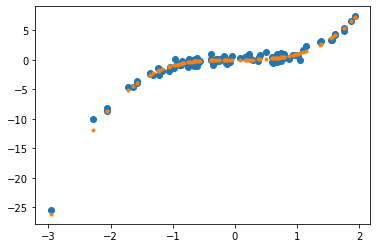

In [42]:
plt.plot(X,y,'o')
plt.plot(X,ytrue,'.')

### Initial value

In [48]:
torch.manual_seed(7)
What = torch.randn(1,requires_grad=True)

In [49]:
What

tensor([-0.1468], requires_grad=True)

In [50]:
yhat=torch.mv(X**3,What)

In [51]:
yhat.data

tensor([ 6.8364e-04, -3.4035e-03,  3.8679e-02,  1.0477e-01,  8.0628e-04,
        -7.8696e-01, -1.0553e+00, -1.4076e-01, -5.2216e-02, -1.5248e-01,
        -1.7953e-03, -1.9019e-01,  1.2079e-01, -9.4988e-02,  7.3863e-03,
        -7.3188e-02, -1.1472e-03, -7.0219e-02, -1.6470e-01,  5.5827e-02,
         8.9804e-02,  2.6455e-01,  7.8075e-05, -3.7047e-01,  1.2860e+00,
        -4.4966e-02,  3.4020e-01,  3.6907e-01,  9.5570e-02,  2.6337e-02,
         1.2767e+00,  6.6635e-03, -1.2870e-01,  4.2562e-02,  8.3467e-02,
         3.2617e-02,  3.6469e-04, -6.1218e-02, -3.3618e-02, -9.5651e-01,
         2.6276e-03,  2.2973e-03, -1.8473e-02, -2.5811e-03,  6.4398e-01,
        -5.7584e-04, -9.0980e-03,  3.7560e-01,  3.8309e+00,  1.7511e-01,
         4.3308e-03, -1.1972e-01,  8.1902e-03,  2.3324e-01, -7.0550e-03,
         4.6163e-03, -2.2036e-01,  8.1946e-03,  6.5822e-03, -6.2974e-02,
        -4.8250e-02,  4.4072e-04, -6.1496e-01, -5.6496e-01,  2.8205e-01,
         7.4403e-01,  2.8997e-02,  3.4203e-02, -5.4

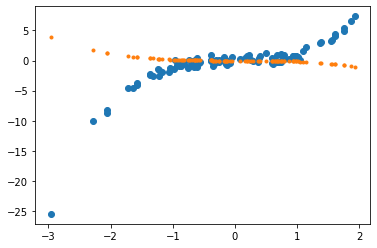

In [52]:
plt.plot(X,y,'o')
plt.plot(X,yhat.data,'.')

### One iteration

In [53]:
loss=torch.mean((y-yhat)**2)
print(loss)

tensor(16.6922, grad_fn=<MeanBackward0>)


In [54]:
loss.backward()

In [55]:
What,What.data

(tensor([-0.1468], requires_grad=True), tensor([-0.1468]))

In [56]:
What.grad.data

tensor([-29.5962])

In [57]:
What.data=What.data - learning_rate * What.grad.data

- ?? 손실함수가 미분이 된다는 보장이 어디에 있나요??

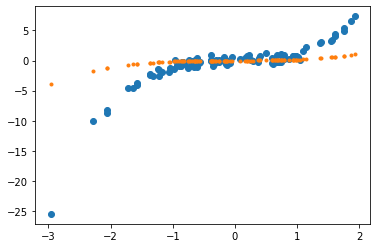

In [60]:
yhat=torch.mv(X**3,What)
plt.plot(X,y,'o')
plt.plot(X,yhat.data,'.')

In [61]:
losses.append(loss.item())

In [62]:
losses

[16.69224739074707]

### Learn (=estimate $\hat{\bf W}$)

In [63]:
for epoc in range(100):
    What.grad = None
    yhat=torch.mv(X**3,What)
    loss=torch.mean((y-yhat)**2)
    loss.backward()
    What.data=What.data - learning_rate * What.grad.data
    losses.append(loss.item())

In [64]:
What.data

tensor([0.9644])

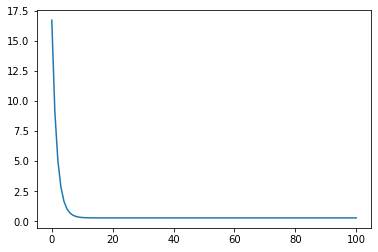

In [65]:
plt.plot(losses)

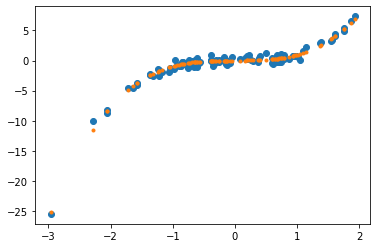

In [66]:
plt.plot(X,y,'o')
plt.plot(X,yhat.data,'.')